In [1]:
from valdpy import ValdAuth, ForeDecksAPI
from valdpy.utils import read_credentials

%load_ext autoreload
%autoreload 2

# ForceDecks API Example

This example demonstrates how to use the VALDPY package to access ForceDecks (force plate) test data.

## Prerequisites

1. Have VALDPY installed: `pip install -e ..`
2. Create a credentials file: Copy `vald_api_cred_TEMPLATE.txt` to `vald_api_cred.txt` and fill in your credentials
3. Ensure your VALD tenant has access to ForceDecks data

In [2]:
# Read credentials from file
creds = read_credentials('vald_api_cred.txt')

client_id = creds['client_id']
client_secret = creds['client_secret']
tenant_id = creds['tenant_id']

print(f"Client ID: {client_id[:10]}...")
print(f"Tenant ID: {tenant_id}")

Client ID: JL3gvSYAr2...
Tenant ID: 61476d2d-917a-4b2e-b2f6-e43346d2cb66


## Step 1: Authentication

Initialize the ValdAuth class to handle OAuth 2.0 authentication and manage tenant/profile information.

In [3]:
# Initialize authentication object
auth = ValdAuth(client_id, client_secret, tenant_id=tenant_id, region='USA')

### Get OAuth Access Token

Call `get_token()` to obtain an access token. This should be your first API call.

In [4]:
# Get access token
token = auth.get_token()
print(f"Token obtained successfully: {token[:20]}...")

Token obtained successfully: eyJhbGciOiJSUzI1NiIs...


### Optional: Get Tenant Information

Retrieve information about your tenant, including available categories and groups.

In [5]:
# Get all tenants accessible with your credentials
all_tenants = auth.get_all_tenants()
print(f"Found {len(all_tenants)} tenant(s)")
for tenant in all_tenants[:3]:
    print(f"  - {tenant['name']} ({tenant['id']})")

Found 1 tenant(s)
  - University of Oregon (61476d2d-917a-4b2e-b2f6-e43346d2cb66)


In [6]:
# Get tenant info
tenant_info = auth.get_tenant_info()
print(f"Tenant Name: {tenant_info.get('name')}")
print(f"Tenant ID: {tenant_info.get('id')}")

Tenant Name: University of Oregon
Tenant ID: 61476d2d-917a-4b2e-b2f6-e43346d2cb66


## Step 2: Get Categories and Groups

Retrieve available categories and groups to organize your profiles.

In [7]:
# Get available categories
categories_df = auth.get_tenant_categories()
print("Available Categories:")
print(categories_df[['name', 'id']].to_string(index=False))

Available Categories:
         name                                   id
Uncategorised 306f33af-2939-480b-bbd7-2ce643c888f0
     Position 3a32a047-1292-49f1-a8aa-8f830ea58ac8
         Team 1fdaf750-970a-4047-badc-945e6e6994cf
        Sport 2828d5d2-ce26-4297-b4c1-a16039889a86


In [8]:
# Get groups for the tenant
groups_df = auth.get_tenant_groups()
print(f"Found {len(groups_df)} group(s)")
print(groups_df[['name', 'id']].head(10).to_string(index=False))

Found 34 group(s)
             name                                   id
Acro and Tumbling 286167da-0a3c-4da9-9b09-316ba9f6e089
Acro and Tumbling 61694101-179d-483f-a8c7-8c5632362760
         Baseball 20588edf-7394-489c-a502-1f0c10c25db8
         Baseball f26a6a9c-7232-4d01-a214-b3f8584ba293
         Football fa4489a4-4a0e-4003-869d-3a7565e82fe4
         Football 935deeb4-f3ba-48a7-ae62-e7f1ead18202
      IR Pitchers fcfe4f19-a3bb-45da-adc6-26c1231d8ece
         Lacrosse 9c1db2c7-2576-489a-99ff-a2f6a0bda4f4
         Lacrosse 95479514-56eb-49c7-adf2-bca891f19140
 Men's Basketball 6b76853c-2062-4b25-926f-4136553de169


## Step 3: Get Profiles

Retrieve athlete profiles from a specific group.

In [9]:
# Get profiles from a specific group
# Replace 'Research' with your desired group name
group_name = 'Research'
category_name = 'Team'

try:
    profiles_df = auth.get_group_profiles(group_name=group_name, category_name=category_name)
    print(f"Found {len(profiles_df)} profile(s) in group '{group_name}'")
    print(profiles_df[['firstName', 'lastName', 'profileId']].head(10).to_string(index=False))
except Exception as e:
    print(f"Error retrieving profiles: {e}")
    print("\nAvailable groups:")
    print(groups_df[['name']].drop_duplicates().to_string(index=False))

Found 11 profile(s) in group 'Research'
Error retrieving profiles: "['firstName', 'lastName'] not in index"

Available groups:
              name
 Acro and Tumbling
          Baseball
          Football
       IR Pitchers
          Lacrosse
  Men's Basketball
        Men's Golf
      Men's Tennis
          Pitchers
          Research
            Soccer
          Softball
             Staff
   Track and Field
        Volleyball
  Volleyball Beach
Women's Basketball
      Women's Golf
    Women's Tennis


## Step 4: Initialize ForceDecks API

Now that we have authentication and profile information, initialize the ForceDecks API client.

In [10]:
# Initialize ForceDecks API client
fd = ForeDecksAPI(tenant_id=auth.tenant_id, header=auth.header, region='USA')

### Get Test Information

Query ForceDecks tests from a specific date. You can optionally filter by profile ID.

In [11]:
# Get tests from a specific date
date = '01/01/2025'  # Format: dd/mm/yyyy

# Optional: filter by profile ID
if len(profiles_df) > 0:
    profile_id = profiles_df.iloc[0]['profileId']
    tests_df = fd.get_tests_info(date, profile_id=profile_id)
else:
    tests_df = fd.get_tests_info(date)

if tests_df is not None:
    print(f"Found {len(tests_df)} test(s) from {date}")
else:
    print(f"No tests found on {date}")

Get request failed.
Found 4 test(s) from 01/01/2025


In [12]:
# View test information
if tests_df is not None and len(tests_df) > 0:
    print(tests_df[['testId', 'profileId', 'modifiedDateUtc']].head())
else:
    print("No test data available. Try a different date range.")

                                 testId                             profileId  \
0  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc  d40fe7d3-cdab-4107-87d9-0fafd0374f21   
1  a80a8c2a-b93a-4d94-9cdb-9def6a4a72dd  d40fe7d3-cdab-4107-87d9-0fafd0374f21   
2  6613932a-16bf-49e8-a7ed-b04809580653  d40fe7d3-cdab-4107-87d9-0fafd0374f21   
3  f1149225-e2bc-4f1c-9dd5-26c259ee6d08  d40fe7d3-cdab-4107-87d9-0fafd0374f21   

            modifiedDateUtc  
0  2025-04-09T18:30:33.887Z  
1  2025-04-09T18:35:44.192Z  
2  2025-07-22T22:52:45.977Z  
3  2025-07-22T22:59:00.291Z  


### Get Test Results

Retrieve detailed results (metrics for each repetition) from a specific test.

In [13]:
# Get results from the first test
if tests_df is not None and len(tests_df) > 0:
    test_id = tests_df.iloc[0]['testId']
    print(f"Retrieving results for test: {test_id}")
    
    response_json, result_defs = fd.get_test_results(test_id)
    print(f"Found {len(fd.results_df)} result(s)")
    print(fd.results_df.head())
else:
    print("No tests available to retrieve results from")

Retrieving results for test: a2ae7e22-1438-40c6-bdf0-bfb2314b98fc
Found 3012 result(s)
   resultId      value    time   limb  repeat  \
0    655365  29.254000  29.254  Trial       0   
1    655366  19.662966  29.254  Trial       0   
2    655367  29.254000  29.254  Trial       0   
3    655386  73.500000   0.000  Trial       0   
4    655387  73.500000   0.000  Trial       0   

                                 testId  rep  \
0  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc    1   
1  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc    1   
2  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc    1   
3  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc    1   
4  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc    1   

                                     id                             athleteId  \
0  845a3074-4d07-48d8-a3c8-526e5d643b51  d40fe7d3-cdab-4107-87d9-0fafd0374f21   
1  845a3074-4d07-48d8-a3c8-526e5d643b51  d40fe7d3-cdab-4107-87d9-0fafd0374f21   
2  845a3074-4d07-48d8-a3c8-526e5d643b51  d40fe7d3-cdab-4107-87d9-0fafd0374f21   
3  84

### Get Raw Force Trace

Retrieve the raw force-time data for a test.

In [14]:
# Get force trace (raw data)
if tests_df is not None and len(tests_df) > 0:
    test_id = tests_df.iloc[0]['testId']
    force_trace = fd.get_force_trace(test_id)
    
    if force_trace is not None:
        print(f"Force trace shape: {force_trace.shape}")
        print(force_trace.head())
    else:
        print("No force trace data available")
else:
    print("No tests available")

Force trace shape: (40077, 4)
    Time      Left     Right                               test_id
0  0.000 -0.949121  0.074931  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc
1  0.002  0.050879  0.074931  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc
2  0.004 -0.949121 -1.925069  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc
3  0.006  0.050879  2.074931  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc
4  0.008  1.050879  0.074931  a2ae7e22-1438-40c6-bdf0-bfb2314b98fc


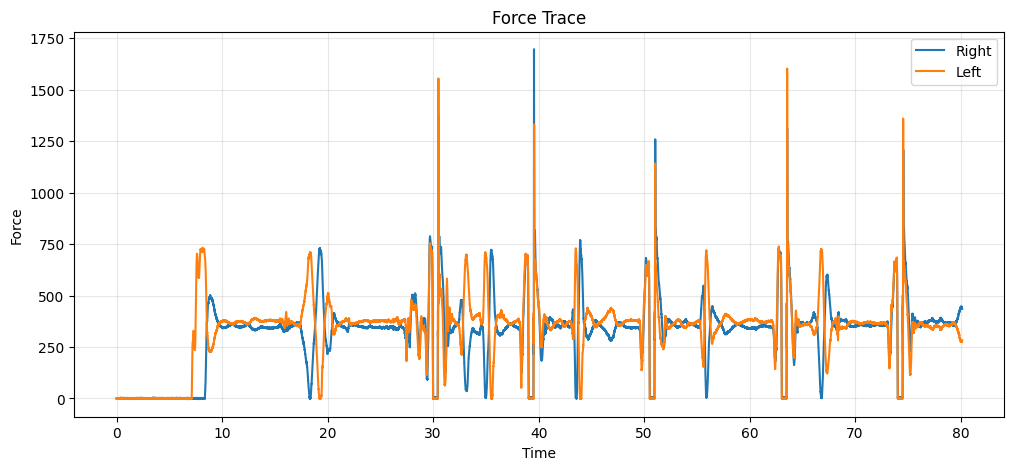

In [16]:
# Visualize force trace (if available)
if force_trace is not None and 'Time' in force_trace.columns:
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 5))
    if 'Right' in force_trace.columns:
        plt.plot(force_trace['Time'], force_trace['Right'], label='Right')
    if 'Left' in force_trace.columns:
        plt.plot(force_trace['Time'], force_trace['Left'], label='Left')
    
    plt.xlabel('Time')
    plt.ylabel('Force')
    plt.title('Force Trace')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Force trace data not available for visualization")